## KMeans

O KMeans é um algoritmo de clusterização que particiona os dados em K clusters. Funciona através dos seguintes passos:

1. **Definir K**: Escolhemos o número de clusters que desejamos formar.

2. **Inicializar Centróides**: Selecionamos aleatoriamente K pontos do dataset como centróides iniciais.

3. **Atribuir Pontos aos Clusters**: Calculamos a distância entre cada ponto do dataset e os K centróides, atribuindo cada ponto ao centróide mais próximo.

4. **Atualizar Centróides**: Calculamos a média (centróide) de cada cluster para corrigir a posição dos centróides.

5. **Repetir**: Os passos 3 e 4 se repetem até que os centróides não mudem mais de posição (convergência).

**Validação**: A melhor forma de encontrar o valor ótimo para K é usar o **gráfico do cotovelo (elbow plot)**, testando diferentes valores de K e observando quando a melhoria na qualidade da clusterização diminui significativamente.

## DBSCAN

O DBSCAN é um algoritmo excelente para dados com distribuição irregular e pontos muito próximos entre si. Funciona através dos seguintes passos:

1. **Core Points (Pontos-núcleo)**: Selecionamos aleatoriamente pontos e traçamos um círculo ao redor deles. Um ponto é considerado Core Point se há um mínimo de pontos (parâmetro eps-min_samples) dentro do raio definido.

2. **Formação de Clusters**: Todos os Core Points que estão próximos entre si formam um cluster.

3. **Inclusão de Non-Core Points**: Pontos que não são Core Points, mas estão próximos de um Core Point, são incluídos no cluster do Core Point mais próximo.

4. **Outliers**: Pontos que não são Core Points e não estão próximos de nenhum Core Point são marcados como outliers (ruído) e não pertencem a nenhum cluster.

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('mall.csv')

In [4]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
# Selecionamos as colunas que usaremos para a clusterização, Gênero por ser uma variável categórica dificultaria e não agregaria ao cluster
# Enquanto idade pode ter uma ampla gama de valores, o que não faria sentido para podermos fazer a clusterização.
x = df.iloc[:, [3,4]].values

In [6]:
# Método de Elbow
from sklearn.cluster import KMeans
# SEE -> soma dos erros quadrados dentro do cluster
see = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i )
    kmeans.fit(x)
    see.append(kmeans.inertia_)

In [7]:
for i in range(len(see)):
    print(f'Número de clusters: {i+1} - SEE: {see[i]:.2f}')
print(f'Minimum SEE: {min(see):.2f}')

Número de clusters: 1 - SEE: 269981.28
Número de clusters: 2 - SEE: 182440.31
Número de clusters: 3 - SEE: 132485.38
Número de clusters: 4 - SEE: 73679.79
Número de clusters: 5 - SEE: 66733.44
Número de clusters: 6 - SEE: 37239.84
Número de clusters: 7 - SEE: 30566.45
Número de clusters: 8 - SEE: 30274.90
Número de clusters: 9 - SEE: 22816.68
Número de clusters: 10 - SEE: 19728.45
Minimum SEE: 19728.45


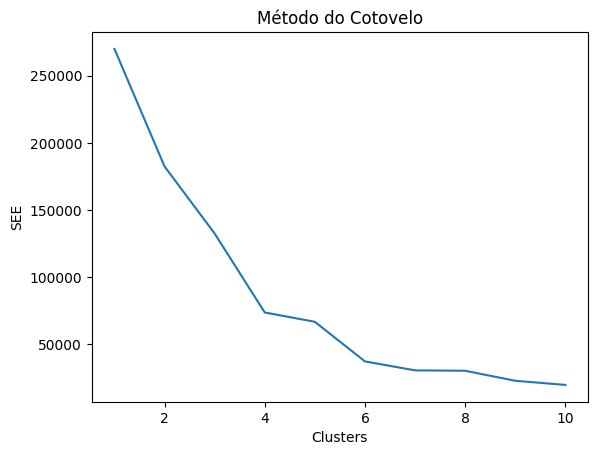

In [8]:
import matplotlib.pyplot as plt
plt.plot(range(1,11), see)
plt.xlabel('Clusters')
plt.ylabel('SEE')
plt.title('Método do Cotovelo')
plt.show()

In [9]:
kmeans_retreinado = KMeans(n_clusters=5)
y_kmeans = kmeans_retreinado.fit_predict(x)

In [10]:
x[y_kmeans == 0, 0], x[y_kmeans == 0, 1]
# O código x[y_kmeans == 0, 0] seleciona os valores da primeira coluna (gastos anuais) para os pontos que pertencem ao cluster 0, enquanto x[y_kmeans == 0, 1] seleciona os valores da segunda coluna (pontuação de gastos) para os mesmos pontos do cluster 0. Isso é feito para plotar os pontos do cluster 0 em um gráfico de dispersão, onde a coordenada x representa os gastos anuais e a coordenada y representa a pontuação de gastos. O mesmo processo é repetido para os outros clusters (1, 2, 3 e 4) para plotar todos os clusters no gráfico.

(array([ 69,  70,  71,  71,  71,  72,  73,  73,  74,  75,  76,  77,  77,
         78,  78,  78,  78,  78,  78,  79,  81,  85,  86,  87,  87,  87,
         88,  88,  93,  97,  98,  99, 101, 103, 103, 113, 120, 126, 137]),
 array([91, 77, 95, 75, 75, 71, 88, 73, 72, 93, 87, 97, 74, 90, 88, 76, 89,
        78, 73, 83, 93, 75, 95, 63, 75, 92, 86, 69, 90, 86, 88, 97, 68, 85,
        69, 91, 79, 74, 83]))

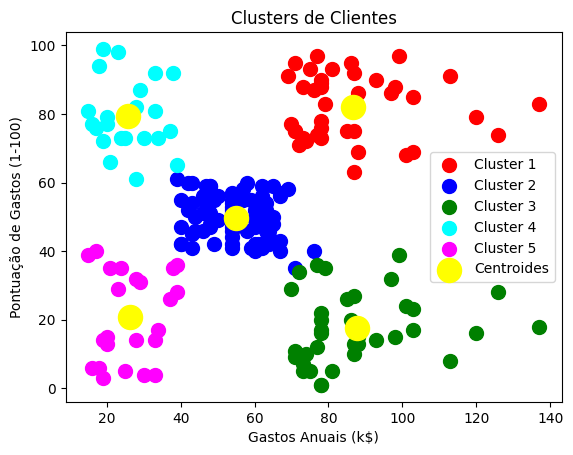

In [11]:
plt.scatter(x[y_kmeans == 0, 0], x[y_kmeans == 0, 1], s=100, c='red', label='Cluster 1')
plt.scatter(x[y_kmeans == 1, 0], x[y_kmeans == 1, 1], s=100, c='blue', label='Cluster 2')
plt.scatter(x[y_kmeans == 2, 0], x[y_kmeans == 2, 1], s=100, c='green', label='Cluster 3')
plt.scatter(x[y_kmeans == 3, 0], x[y_kmeans == 3, 1], s=100, c='cyan', label='Cluster 4')
plt.scatter(x[y_kmeans == 4, 0], x[y_kmeans == 4, 1], s=100, c='magenta', label='Cluster 5')
plt.scatter(kmeans_retreinado.cluster_centers_[:, 0], kmeans_retreinado.cluster_centers_[:, 1], s=300, c='yellow', label='Centroides')

plt.title('Clusters de Clientes')
plt.xlabel('Gastos Anuais (k$)')
plt.ylabel('Pontuação de Gastos (1-100)')
plt.legend()
plt.show()

In [12]:
x = df.iloc[:, [3,4]].values

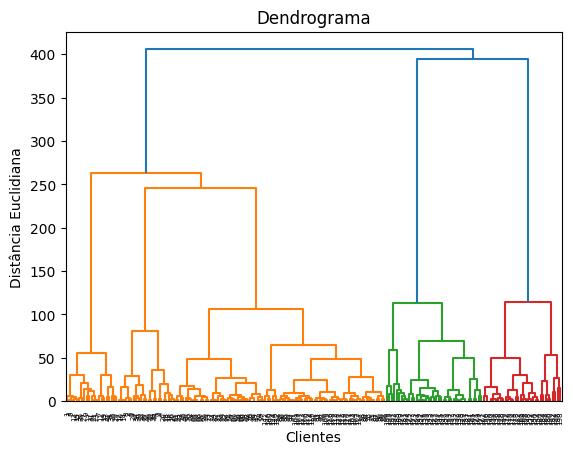

In [14]:
from scipy.cluster.hierarchy import dendrogram, linkage 
dendrogram(linkage(x, method='ward'))
plt.title('Dendrograma')  
plt.xlabel('Clientes')
plt.ylabel('Distância Euclidiana')
plt.show()